# Action Recognition from Photos

This notebook presents a three-class image classification project: sitting, standing, and waving. The dataset was collected from Wikimedia Commons and does not use Kaggle. The experiment compares a HOG + Logistic Regression baseline with MobileNetV3-Small transfer learning.

In [1]:
from pathlib import Path
import csv, json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
metrics = json.loads((RESULTS_DIR / 'metrics.json').read_text())
print('Project root:', ROOT)

Project root: /Users/balgynyerlanqyzy/Desktop/Comp Vision Assik1


## 1. Dataset

I collected 120 images per class with a fixed script. Each local file has a source page, author or credit, license, dimensions, and checksum in the manifest.

In [2]:
manifest = pd.read_csv(DATA_DIR / 'manifest.csv')
summary = manifest.groupby('class').size().rename('images').to_frame()
display(summary)
print('Total images:', len(manifest))
print('Missing source pages:', manifest['source_page'].isna().sum())
print('Missing licenses:', manifest['license'].isna().sum())

,images
class,
sitting,120
standing,120
waving,120


Total images: 360
Missing source pages: 0
Missing licenses: 0


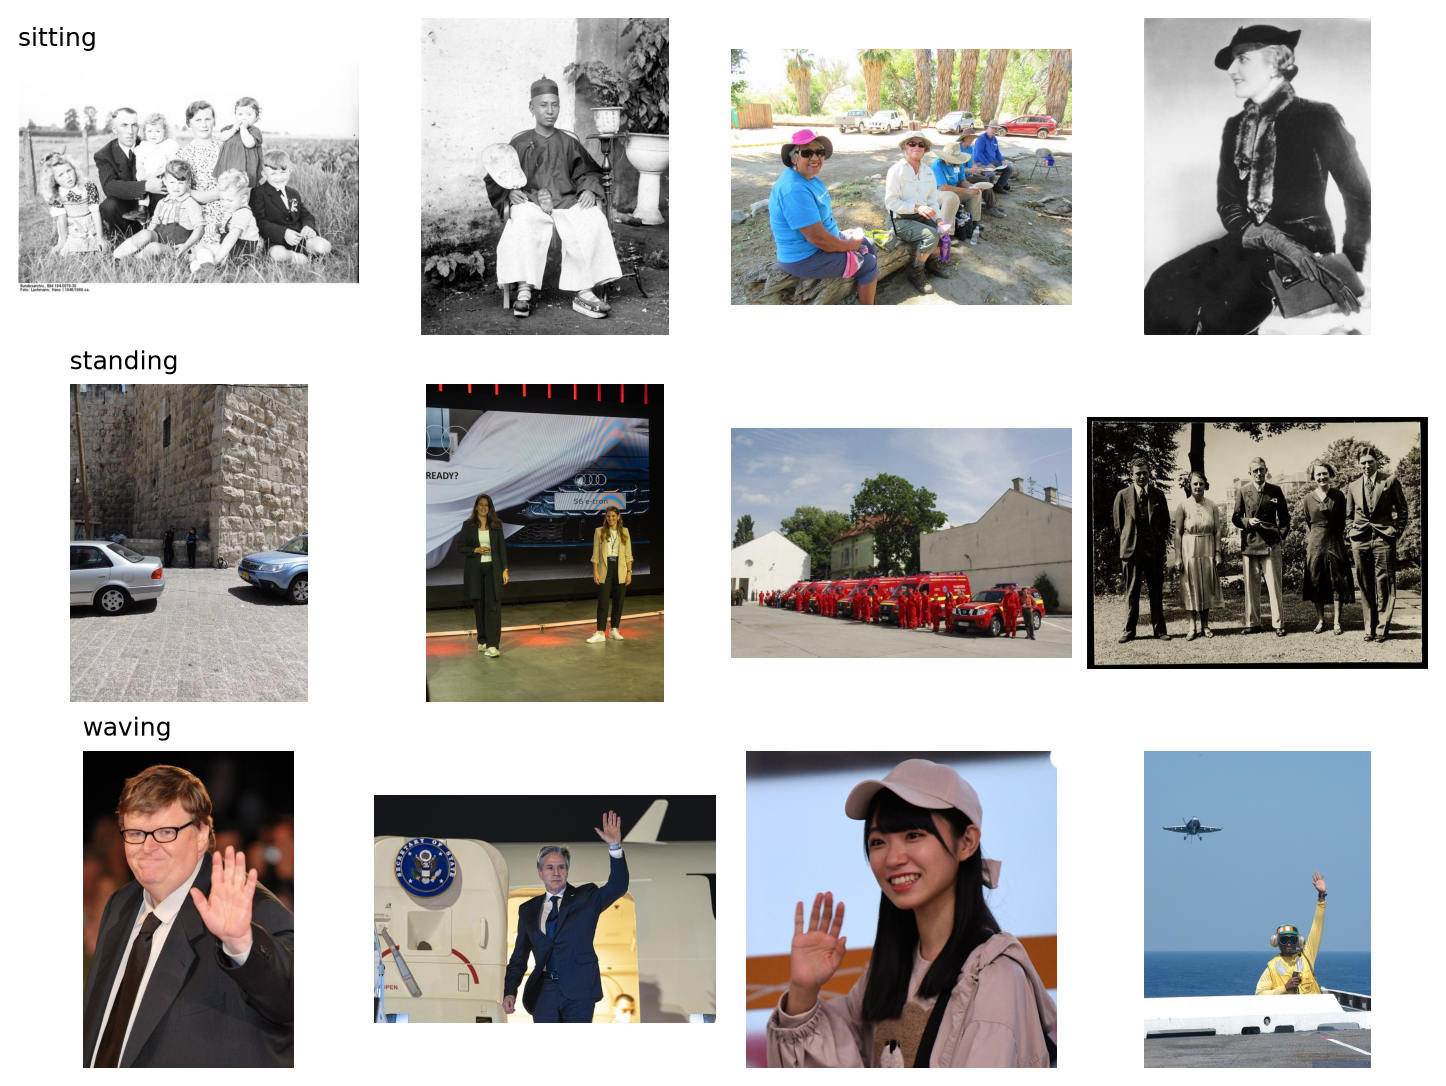

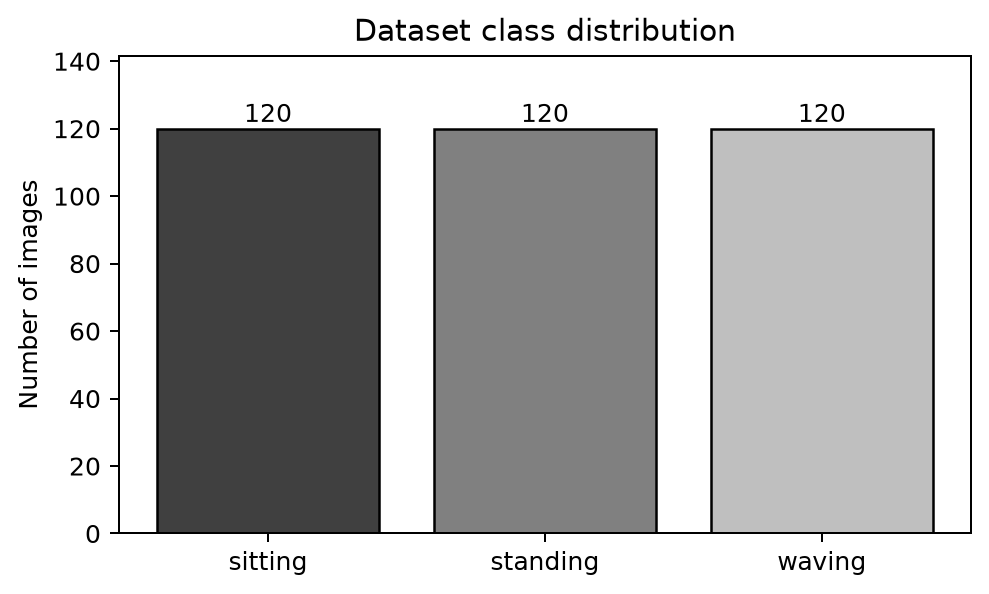

In [3]:
display(Image(filename=str(RESULTS_DIR / 'dataset_examples.png'), width=800))
display(Image(filename=str(RESULTS_DIR / 'class_distribution.png'), width=560))

## 2. Preprocessing and split

The data was divided with stratification into 70% training, 15% validation, and 15% test sets. The random seed was 42. For the baseline, images were resized to 128 x 128 and converted to grayscale before HOG extraction. For transfer learning, training images used random crop, horizontal flip, small rotation, and brightness/contrast change. Validation and test images used deterministic resize and center crop. All deep-model inputs used ImageNet normalization.

In [4]:
splits = pd.read_csv(RESULTS_DIR / 'data_splits.csv')
display(pd.crosstab(splits['split'], splits['class']))
print('Split sizes:', metrics['split_sizes'])

class,sitting,standing,waving
split,,,
test,18,18,18
train,84,84,84
validation,18,18,18


Split sizes: {'train': 252, 'validation': 54, 'test': 54}


## 3. Models

The baseline is Logistic Regression trained on HOG features. This is a simple model that uses edge direction and shape information. The improved model is MobileNetV3-Small pretrained on ImageNet. Its feature extractor was frozen and the classifier was replaced with a three-class layer. The classifier was trained for eight epochs with AdamW and cross-entropy loss.

In [5]:
rows = []
for key, name in [('baseline', 'HOG + Logistic Regression'), ('transfer_learning', 'MobileNetV3-Small')]:
    result = metrics[key]
    rows.append({
        'model': name,
        'accuracy': result['accuracy'],
        'macro precision': result['precision_macro'],
        'macro recall': result['recall_macro'],
        'macro F1': result['f1_macro'],
    })
comparison = pd.DataFrame(rows).set_index('model')
display(comparison.round(3))

,accuracy,macro precision,macro recall,macro F1
model,,,,
HOG + Logistic Regression,0.389,0.394,0.389,0.389
MobileNetV3-Small,0.778,0.783,0.778,0.779


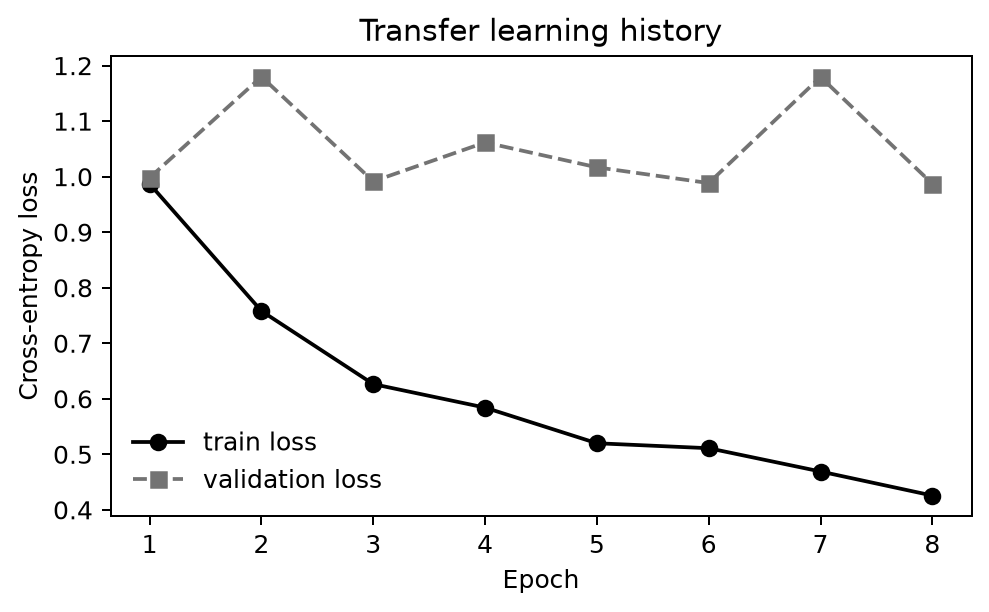

Best validation accuracy: 0.611


In [6]:
display(Image(filename=str(RESULTS_DIR / 'training_history.png'), width=560))
print('Best validation accuracy:', round(metrics['transfer_learning']['best_validation_accuracy'], 3))

## 4. Confusion matrices and class results

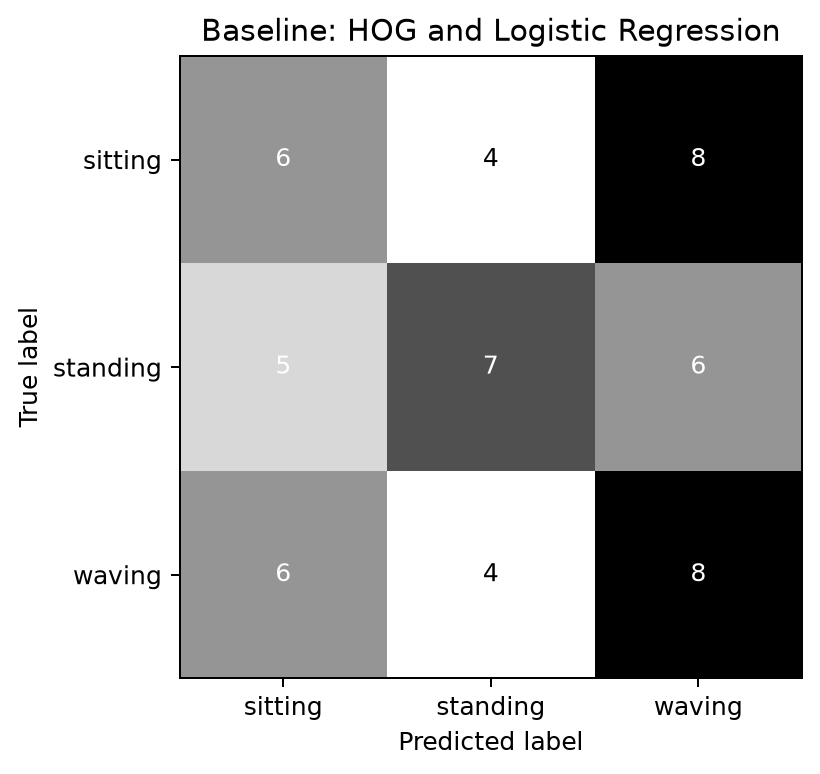

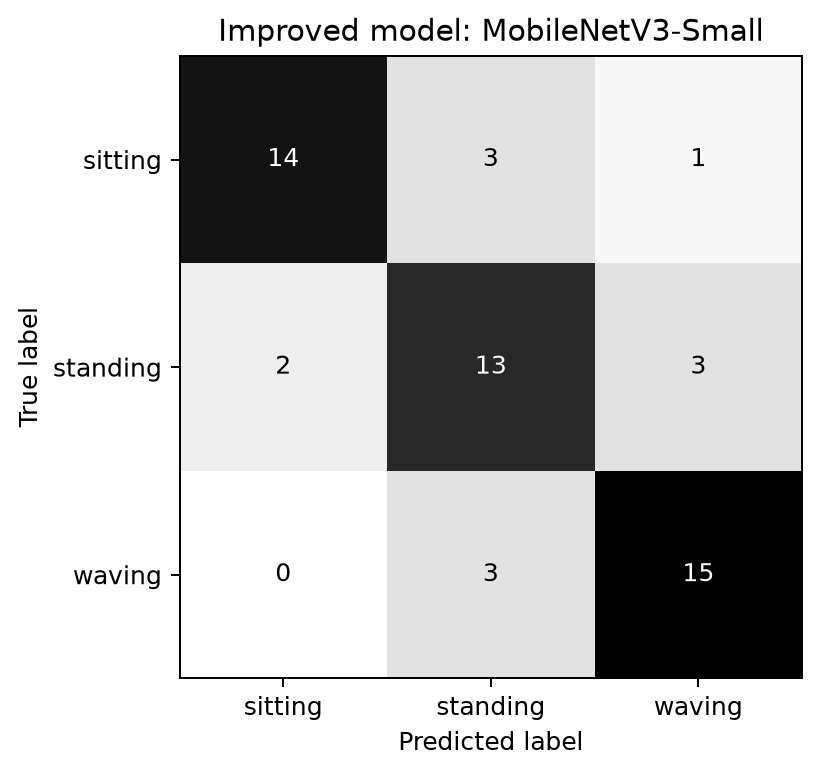

In [7]:
display(Image(filename=str(RESULTS_DIR / 'confusion_baseline.png'), width=500))
display(Image(filename=str(RESULTS_DIR / 'confusion_transfer.png'), width=500))

In [8]:
class_rows = []
report = metrics['transfer_learning']['classification_report']
for class_name in metrics['class_names']:
    class_rows.append({'class': class_name, **report[class_name]})
display(pd.DataFrame(class_rows).set_index('class').round(3))

,precision,recall,f1-score,support
class,,,,
sitting,0.875,0.778,0.824,18.0
standing,0.684,0.722,0.703,18.0
waving,0.789,0.833,0.811,18.0


## 5. Error analysis

The transfer model made fewer errors for every class. The main remaining confusion was between standing and the other classes. This is reasonable because some web photos contain several people or show a person only as a small part of the scene. Waving is also a short motion represented by one still image, so a raised hand can be ambiguous.

In [9]:
predictions = pd.read_csv(RESULTS_DIR / 'test_predictions.csv')
predictions['baseline_correct'] = (predictions.true_class == predictions.baseline_prediction)
predictions['transfer_correct'] = (predictions.true_class == predictions.transfer_prediction)
print('Baseline errors:', (~predictions.baseline_correct).sum())
print('Transfer model errors:', (~predictions.transfer_correct).sum())
display(predictions.loc[~predictions.transfer_correct].head(12))

Baseline errors: 33
Transfer model errors: 12


,filename,true_class,baseline_prediction,transfer_prediction,baseline_correct,transfer_correct
11,raw/standing/standing_079.jpg,standing,standing,sitting,True,False
13,raw/waving/waving_073.jpg,waving,standing,standing,False,False
20,raw/sitting/sitting_042.jpg,sitting,waving,waving,False,False
21,raw/sitting/sitting_102.jpg,sitting,sitting,standing,True,False
22,raw/sitting/sitting_060.jpg,sitting,waving,standing,False,False
26,raw/waving/waving_082.jpg,waving,standing,standing,False,False
27,raw/standing/standing_001.jpg,standing,sitting,sitting,False,False
28,raw/standing/standing_091.jpg,standing,sitting,waving,False,False
32,raw/standing/standing_042.jpg,standing,waving,waving,False,False
39,raw/sitting/sitting_083.jpg,sitting,standing,standing,False,False


## 6. Reproducing the experiment

Set `RUN_TRAINING` to `True` to run the complete training script again. The default is false so opening the submitted notebook does not overwrite saved results.

In [10]:
RUN_TRAINING = False
if RUN_TRAINING:
    import subprocess, sys
    subprocess.run([sys.executable, str(ROOT / 'src' / 'train_models.py'), '--data-dir', str(DATA_DIR), '--output-dir', str(RESULTS_DIR), '--epochs', '8', '--seed', '42'], check=True)

## 7. Conclusion

Transfer learning gave a clear improvement over the baseline. The final test accuracy was 77.8%, compared with 38.9% for HOG + Logistic Regression. This shows that pretrained visual features are useful for pose and action information in a small, varied dataset. More manual label checking and person cropping would probably improve the result further.

### Complete dataset collection code

The complete source is included below for submission. It is disabled in this display cell because the experiment was already run.

In [11]:
if False:
    #!/usr/bin/env python3
    """Collect a reproducible action-recognition dataset from Wikimedia Commons.
    
    The script downloads 120 usable photographs for each class and saves the
    corresponding source page, author, and license in data/manifest.csv.
    """
    
    
    import argparse
    import csv
    import hashlib
    import html
    import json
    import random
    import re
    import subprocess
    import tempfile
    from concurrent.futures import ThreadPoolExecutor
    from pathlib import Path
    from urllib.parse import urlencode
    
    from PIL import Image, ImageOps
    
    
    API_URL = "https://commons.wikimedia.org/w/api.php"
    USER_AGENT = "ActionRecognitionCourseProject/1.0 (educational use)"
    CLASS_CATEGORIES = {
        "sitting": ["People sitting"],
        "standing": ["People standing"],
        "waving": ["Female people waving hands", "Male people waving hands"],
    }
    
    
    def clean_html(value: str) -> str:
        value = re.sub(r"<[^>]+>", " ", value or "")
        return " ".join(html.unescape(value).split())
    
    
    def curl_json(params: dict[str, str]) -> dict:
        command = [
            "curl",
            "-fsSL",
            "--retry",
            "8",
            "--retry-all-errors",
            "--connect-timeout",
            "20",
            "--max-time",
            "90",
            "-A",
            USER_AGENT,
            f"{API_URL}?{urlencode(params)}",
        ]
        result = subprocess.run(command, check=True, capture_output=True)
        return json.loads(result.stdout)
    
    
    def category_candidates(category: str, maximum: int = 500) -> list[dict]:
        records: list[dict] = []
        continuation: dict[str, str] = {}
        while len(records) < maximum:
            params = {
                "action": "query",
                "format": "json",
                "formatversion": "2",
                "generator": "categorymembers",
                "gcmtitle": f"Category:{category}",
                "gcmnamespace": "6",
                "gcmtype": "file",
                "gcmlimit": "500",
                "prop": "imageinfo",
                "iiprop": "url|extmetadata|mime|size|sha1",
                "iiurlwidth": "640",
                **continuation,
            }
            try:
                payload = curl_json(params)
            except subprocess.CalledProcessError:
                if records:
                    break
                raise
            for page in payload.get("query", {}).get("pages", []):
                info = (page.get("imageinfo") or [{}])[0]
                mime = info.get("mime", "")
                if mime in {"image/jpeg", "image/png", "image/webp"}:
                    records.append({"title": page.get("title", ""), **info})
            if "continue" not in payload:
                break
            continuation = {
                key: str(value) for key, value in payload["continue"].items()
            }
        return records[:maximum]
    
    
    def download(url: str, destination: Path) -> bool:
        result = subprocess.run(
            [
                "curl",
                "-fsSL",
                "--retry",
                "1",
                "--retry-all-errors",
                "--connect-timeout",
                "8",
                "--max-time",
                "15",
                "-A",
                USER_AGENT,
                "-o",
                str(destination),
                url,
            ],
            capture_output=True,
        )
        return result.returncode == 0
    
    
    def difference_hash(image: Image.Image) -> int:
        gray = ImageOps.grayscale(image).resize((9, 8), Image.Resampling.LANCZOS)
        pixels = list(gray.getdata())
        bits = 0
        for row in range(8):
            for col in range(8):
                left = pixels[row * 9 + col]
                right = pixels[row * 9 + col + 1]
                bits = (bits << 1) | int(left > right)
        return bits
    
    
    def metadata_value(metadata: dict, key: str) -> str:
        return clean_html(metadata.get(key, {}).get("value", ""))
    
    
    def collect(output: Path, per_class: int, seed: int) -> None:
        randomizer = random.Random(seed)
        output.mkdir(parents=True, exist_ok=True)
        manifest_rows: list[dict[str, str | int]] = []
        global_sha256: set[str] = set()
    
        for class_name, categories in CLASS_CATEGORIES.items():
            class_dir = output / "raw" / class_name
            class_dir.mkdir(parents=True, exist_ok=True)
            candidates: list[dict] = []
            for category in categories:
                candidates.extend(category_candidates(category))
            randomizer.shuffle(candidates)
    
            accepted_hashes: list[int] = []
            accepted = 0
            attempts = 0
            for batch_start in range(0, len(candidates), 24):
                if accepted >= per_class:
                    break
                batch = candidates[batch_start : batch_start + 24]
                with tempfile.TemporaryDirectory() as temp_dir_name:
                    temp_dir = Path(temp_dir_name)
    
                    def fetch(item):
                        index, candidate = item
                        image_url = candidate.get("thumburl") or candidate.get("url")
                        temp_path = temp_dir / f"{index:03d}.image"
                        success = bool(image_url) and download(image_url, temp_path)
                        return candidate, image_url, temp_path, success
    
                    with ThreadPoolExecutor(max_workers=8) as executor:
                        downloaded = list(executor.map(fetch, enumerate(batch)))
    
                    for candidate, image_url, temp_path, success in downloaded:
                        if accepted >= per_class:
                            break
                        attempts += 1
                        if not success:
                            continue
                        try:
                            raw_bytes = temp_path.read_bytes()
                            digest = hashlib.sha256(raw_bytes).hexdigest()
                            if digest in global_sha256:
                                continue
                            with Image.open(temp_path) as source:
                                image = ImageOps.exif_transpose(source).convert("RGB")
                                width, height = image.size
                                if min(width, height) < 180:
                                    continue
                                perceptual = difference_hash(image)
                                if any((perceptual ^ old).bit_count() <= 3 for old in accepted_hashes):
                                    continue
                                filename = f"{class_name}_{accepted + 1:03d}.jpg"
                                destination = class_dir / filename
                                image.thumbnail((640, 640), Image.Resampling.LANCZOS)
                                image.save(destination, "JPEG", quality=90, optimize=True)
                            metadata = candidate.get("extmetadata", {})
                            page_url = candidate.get("descriptionurl", "")
                            manifest_rows.append(
                                {
                                    "filename": f"raw/{class_name}/{filename}",
                                    "class": class_name,
                                    "source_page": page_url,
                                    "image_url": image_url,
                                    "title": candidate.get("title", ""),
                                    "author": metadata_value(metadata, "Artist") or metadata_value(metadata, "Credit"),
                                    "license": metadata_value(metadata, "LicenseShortName"),
                                    "license_url": metadata_value(metadata, "LicenseUrl"),
                                    "original_width": width,
                                    "original_height": height,
                                    "sha256": digest,
                                }
                            )
                            accepted_hashes.append(perceptual)
                            global_sha256.add(digest)
                            accepted += 1
                            print(f"{class_name}: {accepted}/{per_class}", flush=True)
                        except (OSError, ValueError):
                            continue
    
            if accepted < per_class:
                raise RuntimeError(
                    f"Only {accepted} valid images found for {class_name} after {attempts} attempts"
                )
    
        manifest_path = output / "manifest.csv"
        with manifest_path.open("w", newline="", encoding="utf-8") as stream:
            writer = csv.DictWriter(stream, fieldnames=list(manifest_rows[0]))
            writer.writeheader()
            writer.writerows(manifest_rows)
    
        summary = {
            "source": "Wikimedia Commons",
            "collection_method": "MediaWiki API category members",
            "seed": seed,
            "classes": {
                name: sum(row["class"] == name for row in manifest_rows)
                for name in CLASS_CATEGORIES
            },
            "total_images": len(manifest_rows),
        }
        (output / "dataset_summary.json").write_text(
            json.dumps(summary, indent=2), encoding="utf-8"
        )
    
    
    def main() -> None:
        parser = argparse.ArgumentParser()
        parser.add_argument("--output", type=Path, default=Path("data"))
        parser.add_argument("--per-class", type=int, default=120)
        parser.add_argument("--seed", type=int, default=42)
        args = parser.parse_args()
        collect(args.output, args.per_class, args.seed)
    
    
    if __name__ == "__main__":
        main()

### Complete training and evaluation code

The complete source is included below for submission. It is disabled in this display cell because the experiment was already run.

In [12]:
if False:
    #!/usr/bin/env python3
    """Train and evaluate baseline and transfer-learning action classifiers."""
    
    
    import argparse
    import csv
    import json
    import random
    from pathlib import Path
    
    import cv2
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    from PIL import Image
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        confusion_matrix,
        precision_recall_fscore_support,
    )
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
    from torchvision import models, transforms
    
    
    CLASSES = ["sitting", "standing", "waving"]
    
    
    def set_seed(seed: int) -> None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
    
    
    def read_manifest(data_dir: Path) -> list[dict[str, str]]:
        with (data_dir / "manifest.csv").open(encoding="utf-8") as stream:
            return list(csv.DictReader(stream))
    
    
    def split_records(records: list[dict[str, str]], seed: int):
        labels = [row["class"] for row in records]
        train, remainder = train_test_split(
            records, test_size=0.30, random_state=seed, stratify=labels
        )
        remainder_labels = [row["class"] for row in remainder]
        validation, test = train_test_split(
            remainder,
            test_size=0.50,
            random_state=seed,
            stratify=remainder_labels,
        )
        return train, validation, test
    
    
    def save_split_csv(splits: dict[str, list[dict[str, str]]], output_dir: Path) -> None:
        with (output_dir / "data_splits.csv").open("w", newline="", encoding="utf-8") as stream:
            writer = csv.writer(stream)
            writer.writerow(["filename", "class", "split"])
            for split_name, rows in splits.items():
                for row in rows:
                    writer.writerow([row["filename"], row["class"], split_name])
    
    
    def hog_features(data_dir: Path, records: list[dict[str, str]]) -> np.ndarray:
        descriptor = cv2.HOGDescriptor(
            (128, 128), (32, 32), (16, 16), (16, 16), 9
        )
        features = []
        for row in records:
            image = cv2.imread(str(data_dir / row["filename"]))
            image = cv2.resize(image, (128, 128), interpolation=cv2.INTER_AREA)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            features.append(descriptor.compute(image).ravel())
        return np.asarray(features, dtype=np.float32)
    
    
    def metric_summary(y_true: list[int], y_pred: list[int]) -> dict:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )
        return {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision_macro": float(precision),
            "recall_macro": float(recall),
            "f1_macro": float(f1),
            "classification_report": classification_report(
                y_true,
                y_pred,
                labels=list(range(len(CLASSES))),
                target_names=CLASSES,
                output_dict=True,
                zero_division=0,
            ),
            "confusion_matrix": confusion_matrix(
                y_true, y_pred, labels=list(range(len(CLASSES)))
            ).tolist(),
        }
    
    
    def train_baseline(data_dir: Path, train_rows: list[dict], test_rows: list[dict]):
        label_to_id = {name: index for index, name in enumerate(CLASSES)}
        x_train = hog_features(data_dir, train_rows)
        x_test = hog_features(data_dir, test_rows)
        y_train = np.asarray([label_to_id[row["class"]] for row in train_rows])
        y_test = np.asarray([label_to_id[row["class"]] for row in test_rows])
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1500, C=1.0, random_state=42),
        )
        model.fit(x_train, y_train)
        predictions = model.predict(x_test)
        return model, metric_summary(y_test.tolist(), predictions.tolist()), predictions.tolist()
    
    
    class ActionDataset(Dataset):
        def __init__(self, data_dir: Path, rows: list[dict], transform):
            self.data_dir = data_dir
            self.rows = rows
            self.transform = transform
            self.label_to_id = {name: index for index, name in enumerate(CLASSES)}
    
        def __len__(self) -> int:
            return len(self.rows)
    
        def __getitem__(self, index: int):
            row = self.rows[index]
            with Image.open(self.data_dir / row["filename"]) as source:
                image = source.convert("RGB")
            return self.transform(image), self.label_to_id[row["class"]]
    
    
    def deep_transforms():
        normalization = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        )
        train_transform = transforms.Compose(
            [
                transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(8),
                transforms.ColorJitter(brightness=0.15, contrast=0.15),
                transforms.ToTensor(),
                normalization,
            ]
        )
        evaluation_transform = transforms.Compose(
            [
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                normalization,
            ]
        )
        return train_transform, evaluation_transform
    
    
    def evaluate_deep(model, loader, criterion, device):
        model.eval()
        total_loss = 0.0
        true_labels: list[int] = []
        predictions: list[int] = []
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                total_loss += criterion(logits, labels).item() * images.size(0)
                true_labels.extend(labels.cpu().tolist())
                predictions.extend(logits.argmax(dim=1).cpu().tolist())
        return total_loss / len(loader.dataset), true_labels, predictions
    
    
    def train_transfer_model(
        data_dir: Path,
        train_rows: list[dict],
        validation_rows: list[dict],
        test_rows: list[dict],
        output_dir: Path,
        epochs: int,
    ):
        train_transform, evaluation_transform = deep_transforms()
        train_loader = DataLoader(
            ActionDataset(data_dir, train_rows, train_transform),
            batch_size=16,
            shuffle=True,
            num_workers=0,
        )
        validation_loader = DataLoader(
            ActionDataset(data_dir, validation_rows, evaluation_transform),
            batch_size=16,
            shuffle=False,
            num_workers=0,
        )
        test_loader = DataLoader(
            ActionDataset(data_dir, test_rows, evaluation_transform),
            batch_size=16,
            shuffle=False,
            num_workers=0,
        )
    
        device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        model = models.mobilenet_v3_small(weights=weights)
        for parameter in model.features.parameters():
            parameter.requires_grad = False
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(CLASSES))
        model.to(device)
    
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(
            [parameter for parameter in model.parameters() if parameter.requires_grad],
            lr=1e-3,
            weight_decay=1e-4,
        )
        history = {"train_loss": [], "validation_loss": [], "validation_accuracy": []}
        best_accuracy = -1.0
        best_path = output_dir / "mobilenet_v3_small_best.pt"
    
        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                logits = model(images)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * images.size(0)
            train_loss = running_loss / len(train_loader.dataset)
            validation_loss, validation_true, validation_pred = evaluate_deep(
                model, validation_loader, criterion, device
            )
            validation_accuracy = accuracy_score(validation_true, validation_pred)
            history["train_loss"].append(float(train_loss))
            history["validation_loss"].append(float(validation_loss))
            history["validation_accuracy"].append(float(validation_accuracy))
            print(
                f"epoch {epoch + 1}/{epochs}: train_loss={train_loss:.4f}, "
                f"val_loss={validation_loss:.4f}, val_accuracy={validation_accuracy:.4f}"
            )
            if validation_accuracy > best_accuracy:
                best_accuracy = validation_accuracy
                torch.save(model.state_dict(), best_path)
    
        model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
        test_loss, test_true, test_predictions = evaluate_deep(
            model, test_loader, criterion, device
        )
        metrics = metric_summary(test_true, test_predictions)
        metrics["test_loss"] = float(test_loss)
        metrics["best_validation_accuracy"] = float(best_accuracy)
        metrics["device"] = str(device)
        return model, metrics, history, test_true, test_predictions
    
    
    def plot_confusion(matrix: list[list[int]], title: str, path: Path) -> None:
        array = np.asarray(matrix)
        figure, axis = plt.subplots(figsize=(5.2, 4.4))
        axis.imshow(array, cmap="Greys")
        for row in range(array.shape[0]):
            for col in range(array.shape[1]):
                threshold = array.max() / 2 if array.max() else 0
                axis.text(
                    col,
                    row,
                    str(array[row, col]),
                    ha="center",
                    va="center",
                    color="white" if array[row, col] > threshold else "black",
                )
        axis.set_xticks(range(len(CLASSES)), CLASSES)
        axis.set_yticks(range(len(CLASSES)), CLASSES)
        axis.set_xlabel("Predicted label")
        axis.set_ylabel("True label")
        axis.set_title(title)
        figure.tight_layout()
        figure.savefig(path, dpi=180, bbox_inches="tight")
        plt.close(figure)
    
    
    def create_figures(
        data_dir: Path,
        output_dir: Path,
        records: list[dict],
        baseline_metrics: dict,
        transfer_metrics: dict,
        history: dict,
    ) -> None:
        counts = [sum(row["class"] == name for row in records) for name in CLASSES]
        figure, axis = plt.subplots(figsize=(5.6, 3.4))
        axis.bar(CLASSES, counts, color=["0.25", "0.50", "0.75"], edgecolor="black")
        axis.set_ylabel("Number of images")
        axis.set_title("Dataset class distribution")
        axis.set_ylim(0, max(counts) * 1.18)
        for index, value in enumerate(counts):
            axis.text(index, value + 2, str(value), ha="center")
        figure.tight_layout()
        figure.savefig(output_dir / "class_distribution.png", dpi=180, bbox_inches="tight")
        plt.close(figure)
    
        figure, axes = plt.subplots(3, 4, figsize=(8.0, 6.0))
        for row_index, class_name in enumerate(CLASSES):
            examples = [row for row in records if row["class"] == class_name][:4]
            for col_index, row in enumerate(examples):
                with Image.open(data_dir / row["filename"]) as image:
                    axes[row_index, col_index].imshow(image.convert("RGB"))
                axes[row_index, col_index].axis("off")
                if col_index == 0:
                    axes[row_index, col_index].set_title(class_name, loc="left", fontsize=10)
        figure.tight_layout(pad=0.6)
        figure.savefig(output_dir / "dataset_examples.png", dpi=180, bbox_inches="tight")
        plt.close(figure)
    
        epochs = range(1, len(history["train_loss"]) + 1)
        figure, axis = plt.subplots(figsize=(5.6, 3.5))
        axis.plot(epochs, history["train_loss"], "-o", color="black", label="train loss")
        axis.plot(
            epochs,
            history["validation_loss"],
            "--s",
            color="0.45",
            label="validation loss",
        )
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Cross-entropy loss")
        axis.set_title("Transfer learning history")
        axis.legend(frameon=False)
        figure.tight_layout()
        figure.savefig(output_dir / "training_history.png", dpi=180, bbox_inches="tight")
        plt.close(figure)
    
        plot_confusion(
            baseline_metrics["confusion_matrix"],
            "Baseline: HOG and Logistic Regression",
            output_dir / "confusion_baseline.png",
        )
        plot_confusion(
            transfer_metrics["confusion_matrix"],
            "Improved model: MobileNetV3-Small",
            output_dir / "confusion_transfer.png",
        )
    
    
    def main() -> None:
        parser = argparse.ArgumentParser()
        parser.add_argument("--data-dir", type=Path, default=Path("data"))
        parser.add_argument("--output-dir", type=Path, default=Path("results"))
        parser.add_argument("--epochs", type=int, default=8)
        parser.add_argument("--seed", type=int, default=42)
        args = parser.parse_args()
    
        set_seed(args.seed)
        args.output_dir.mkdir(parents=True, exist_ok=True)
        records = read_manifest(args.data_dir)
        train_rows, validation_rows, test_rows = split_records(records, args.seed)
        splits = {"train": train_rows, "validation": validation_rows, "test": test_rows}
        save_split_csv(splits, args.output_dir)
    
        _, baseline_metrics, baseline_predictions = train_baseline(
            args.data_dir, train_rows, test_rows
        )
        _, transfer_metrics, history, test_true, transfer_predictions = train_transfer_model(
            args.data_dir,
            train_rows,
            validation_rows,
            test_rows,
            args.output_dir,
            args.epochs,
        )
    
        results = {
            "seed": args.seed,
            "class_names": CLASSES,
            "dataset_size": len(records),
            "split_sizes": {name: len(rows) for name, rows in splits.items()},
            "baseline": baseline_metrics,
            "transfer_learning": transfer_metrics,
            "history": history,
        }
        (args.output_dir / "metrics.json").write_text(
            json.dumps(results, indent=2), encoding="utf-8"
        )
        with (args.output_dir / "test_predictions.csv").open(
            "w", newline="", encoding="utf-8"
        ) as stream:
            writer = csv.writer(stream)
            writer.writerow(["filename", "true_class", "baseline_prediction", "transfer_prediction"])
            for row, baseline, transfer in zip(
                test_rows, baseline_predictions, transfer_predictions
            ):
                writer.writerow([row["filename"], row["class"], CLASSES[baseline], CLASSES[transfer]])
    
        create_figures(
            args.data_dir,
            args.output_dir,
            records,
            baseline_metrics,
            transfer_metrics,
            history,
        )
        print(json.dumps({"baseline": baseline_metrics, "transfer": transfer_metrics}, indent=2))
    
    
    if __name__ == "__main__":
        main()